### **Introduction**

The objective of this study is to predict weld quality in steels, an issue that involves billions of euros in the industry, such as in the welding of tubes for wind turbines. Currently, knowledge about weld quality depends heavily on human experience (passed from specialist to specialist). The goal of this study is to manipulate, analyze, and infer patterns related to weld quality through machine learning models studied in the Apprentissage Automatique course (3IF3010) using the Weld Database.

In this first step, we will import the essential libraries and download the suggested public data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/welddb.data', sep=r'\s+', header=None)

print(df.head())

      0     1     2      3      4  5  6  7  8  9   ...   34   35 36 37  38  \
0  0.037  0.30  0.65  0.008  0.012  0  N  N  N  N  ...    N    N  N  N   N   
1  0.037  0.30  0.65  0.008  0.012  0  N  N  N  N  ...  -28  100  N  N   N   
2  0.037  0.30  0.65  0.008  0.012  0  N  N  N  N  ...  -38  100  N  N   N   
3  0.037  0.31  1.03  0.007  0.014  0  N  N  N  N  ...    N    N  N  N   N   
4  0.037  0.31  1.03  0.007  0.014  0  N  N  N  N  ...  -48  100  N  N  32   

   39  40 41 42                             43  
0   N   N  N  N    Evans-Ni/CMn-1990/1991-0Aaw  
1   N   N  N  N  Evans-Ni/CMn-1990/1991-0Aawch  
2   N   N  N  N    Evans-Ni/CMn-1990/1991-0Aht  
3   N   N  N  N    Evans-Ni/CMn-1990/1991-0Baw  
4  28  40  0  0  Evans-Ni/CMn-1990/1991-0Bawch  

[5 rows x 44 columns]


In [2]:
column_names = [
    "Carbon_C", "Silicon_Si", "Manganese_Mn", "Sulphur_S", "Phosphorus_P",
    "Nickel_Ni", "Chromium_Cr", "Molybdenum_Mo", "Vanadium_V", "Copper_Cu",
    "Cobalt_Co", "Tungsten_W", "Oxygen_O_ppm", "Titanium_Ti_ppm", "Nitrogen_N_ppm",
    "Aluminium_Al_ppm", "Boron_B_ppm", "Niobium_Nb_ppm", "Tin_Sn_ppm", "Arsenic_As_ppm",
    "Antimony_Sb_ppm", "Current_A", "Voltage_V", "AC_DC", "Electrode_Pos_Neg",
    "Heat_input_kJ_mm", "Interpass_temp_C", "Type_of_weld", "Post_weld_temp_C",
    "Post_weld_time_h", "Yield_strength_MPa", "Ultimate_tensile_strength_MPa",
    "Elongation_pct", "Reduction_of_Area_pct", "Charpy_temp_C", "Charpy_toughness_J",
    "Hardness_kg_mm2", "FATT_50_pct", "Primary_ferrite_pct", "Ferrite_second_phase_pct",
    "Acicular_ferrite_pct", "Martensite_pct", "Ferrite_carbide_aggregate_pct", "Weld_ID"
]

df.columns = column_names

# Replacing missing value placeholders with actual NaNs
df = df.replace('N', np.nan)

print("Columns successfully renamed! New DataFrame structure:")
display(df.info())

Columns successfully renamed! New DataFrame structure:
<class 'pandas.DataFrame'>
RangeIndex: 1652 entries, 0 to 1651
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Carbon_C                       1652 non-null   float64
 1   Silicon_Si                     1652 non-null   float64
 2   Manganese_Mn                   1652 non-null   float64
 3   Sulphur_S                      1648 non-null   str    
 4   Phosphorus_P                   1642 non-null   str    
 5   Nickel_Ni                      697 non-null    str    
 6   Chromium_Cr                    784 non-null    str    
 7   Molybdenum_Mo                  793 non-null    str    
 8   Vanadium_V                     928 non-null    str    
 9   Copper_Cu                      578 non-null    str    
 10  Cobalt_Co                      129 non-null    str    
 11  Tungsten_W                     75 non-null     str    
 12  Oxyg

None

In [3]:
# Initialize a clean DataFrame
df_cleaned = df.copy()

# Convert all columns to numeric format
for col in df_cleaned.columns:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

# Keep only columns with at least 50% non-null values
threshold_na = len(df_cleaned) * 0.5
df_cleaned = df_cleaned.dropna(thresh=threshold_na, axis=1)

# Drop remaining rows containing any null values in key columns
df_cleaned = df_cleaned.dropna()

# Select the second to last numeric column as the target (Charpy_temp_C)
target_col = df_cleaned.columns[-2]

if len(df_cleaned) > 0:
    median_threshold = df_cleaned[target_col].median()
    df_cleaned['Quality_class'] = np.where(df_cleaned[target_col] >= median_threshold, 'High Quality', 'Low Quality')

    print(f"Dataset cleaned successfully! Final dimensions: {df_cleaned.shape[0]} rows and {df_cleaned.shape[1] - 1} predictor columns.\n")
    print(f"Selected target for class division: {target_col}\n")
    print("Descriptive Statistics grouped by Quality Class:\n")
    for quality_class, group_data in df_cleaned.groupby('Quality_class'):
        print(f"=== Class: {quality_class} ===")
        display(group_data.drop(columns=['Quality_class']).describe())
else:
    print("Error: The dataset is empty after processing. Adjusting the cleaning strategy.")

df_cleaned.info()

Dataset cleaned successfully! Final dimensions: 307 rows and 16 predictor columns.

Selected target for class division: Charpy_temp_C

Descriptive Statistics grouped by Quality Class:

=== Class: High Quality ===


,Carbon_C,Silicon_Si,Manganese_Mn,Sulphur_S,Phosphorus_P,Oxygen_O_ppm,Titanium_Ti_ppm,Nitrogen_N_ppm,Current_A,Voltage_V,Heat_input_kJ_mm,Interpass_temp_C,Post_weld_temp_C,Post_weld_time_h,Charpy_temp_C,Charpy_toughness_J
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,0.075271,0.386387,1.314258,0.007852,0.009194,367.374194,103.980645,75.903226,215.161290,22.677419,1.294194,220.645161,93.548387,0.322581,-17.458065,111.677419
std,0.021807,0.089630,0.467924,0.002864,0.003171,82.451257,84.796507,18.786834,140.986114,2.873831,1.018864,24.697584,214.014631,0.737981,24.466579,42.899147
min,0.030000,0.240000,0.620000,0.002000,0.004000,132.000000,4.000000,36.000000,170.000000,21.000000,1.000000,200.000000,0.000000,0.000000,-48.000000,12.000000
25%,0.070000,0.330000,0.925000,0.006000,0.006000,320.000000,37.000000,63.000000,170.000000,21.000000,1.000000,200.000000,0.000000,0.000000,-40.000000,100.000000
50%,0.075000,0.360000,1.350000,0.008000,0.010000,396.000000,100.000000,76.000000,170.000000,21.000000,1.000000,200.000000,0.000000,0.000000,-20.000000,100.000000
75%,0.080000,0.430000,1.720000,0.010000,0.010500,430.000000,140.000000,88.000000,180.000000,23.000000,1.000000,250.000000,0.000000,0.000000,0.000000,141.500000
max,0.130000,0.680000,2.250000,0.013000,0.017000,491.000000,460.000000,119.000000,700.000000,32.000000,4.800000,250.000000,580.000000,2.000000,55.000000,212.000000


=== Class: Low Quality ===


,Carbon_C,Silicon_Si,Manganese_Mn,Sulphur_S,Phosphorus_P,Oxygen_O_ppm,Titanium_Ti_ppm,Nitrogen_N_ppm,Current_A,Voltage_V,Heat_input_kJ_mm,Interpass_temp_C,Post_weld_temp_C,Post_weld_time_h,Charpy_temp_C,Charpy_toughness_J
count,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.0,152.000000,152.000000,152.000000,152.000000,152.000000
mean,0.074520,0.359079,1.353618,0.006454,0.007138,394.046053,100.960526,73.828947,171.052632,21.210526,1.0,205.263158,160.263158,0.552632,-63.703947,76.894737
std,0.011552,0.070254,0.309857,0.001775,0.001963,47.248020,109.747445,15.574549,3.079067,0.615813,0.0,15.395336,260.218826,0.897306,9.496489,33.346497
min,0.030000,0.240000,0.630000,0.002000,0.004000,272.000000,4.000000,36.000000,170.000000,21.000000,1.0,200.000000,0.000000,0.000000,-99.000000,5.000000
25%,0.071000,0.310000,1.097500,0.005000,0.006000,373.000000,35.000000,65.000000,170.000000,21.000000,1.0,200.000000,0.000000,0.000000,-68.250000,28.000000
50%,0.076000,0.345000,1.360000,0.007000,0.007000,407.500000,43.000000,75.500000,170.000000,21.000000,1.0,200.000000,0.000000,0.000000,-61.000000,100.000000
75%,0.077000,0.390000,1.492500,0.007000,0.008000,423.000000,132.500000,83.000000,170.000000,21.000000,1.0,200.000000,580.000000,2.000000,-56.000000,100.000000
max,0.130000,0.570000,2.250000,0.013000,0.014000,491.000000,460.000000,119.000000,180.000000,23.000000,1.0,250.000000,580.000000,2.000000,-49.000000,100.000000


<class 'pandas.DataFrame'>
Index: 307 entries, 71 to 906
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Carbon_C            307 non-null    float64
 1   Silicon_Si          307 non-null    float64
 2   Manganese_Mn        307 non-null    float64
 3   Sulphur_S           307 non-null    float64
 4   Phosphorus_P        307 non-null    float64
 5   Oxygen_O_ppm        307 non-null    float64
 6   Titanium_Ti_ppm     307 non-null    float64
 7   Nitrogen_N_ppm      307 non-null    float64
 8   Current_A           307 non-null    float64
 9   Voltage_V           307 non-null    float64
 10  Heat_input_kJ_mm    307 non-null    float64
 11  Interpass_temp_C    307 non-null    float64
 12  Post_weld_temp_C    307 non-null    float64
 13  Post_weld_time_h    307 non-null    float64
 14  Charpy_temp_C       307 non-null    float64
 15  Charpy_toughness_J  307 non-null    float64
 16  Quality_class       307

Data Nature and Cleaning

In [4]:
# Convert all columns to numeric format
for col in df_cleaned.columns:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

# Keep only columns with at least 50% non-null values
threshold_na = len(df_cleaned) * 0.5
df_cleaned = df_cleaned.dropna(thresh=threshold_na, axis=1)

# Drop remaining rows containing any null values in key columns
df_cleaned = df_cleaned.dropna()

# Select the target as the last remaining column after cleaning
target_col = df_cleaned.columns[-1]

if len(df_cleaned) > 0:
    median_threshold = df_cleaned[target_col].median()
    df_cleaned['Quality_class'] = np.where(df_cleaned[target_col] >= median_threshold, 'High Quality', 'Low Quality')

    print(f"Dataset cleaned successfully! Final dimensions: {df_cleaned.shape[0]} rows and {df_cleaned.shape[1] - 1} predictor columns.\n")
    print("Descriptive Statistics grouped by Quality Class:\n")
    for quality_class, group_data in df_cleaned.groupby('Quality_class'):
        print(f"=== Class: {quality_class} ===")
        display(group_data.drop(columns=['Quality_class']).describe())
else:
    print("Error: The dataset is still empty. Adjusting the cleaning strategy to essential columns.")

Dataset cleaned successfully! Final dimensions: 307 rows and 16 predictor columns.

Descriptive Statistics grouped by Quality Class:

=== Class: High Quality ===


,Carbon_C,Silicon_Si,Manganese_Mn,Sulphur_S,Phosphorus_P,Oxygen_O_ppm,Titanium_Ti_ppm,Nitrogen_N_ppm,Current_A,Voltage_V,Heat_input_kJ_mm,Interpass_temp_C,Post_weld_temp_C,Post_weld_time_h,Charpy_temp_C,Charpy_toughness_J
count,229.000000,229.000000,229.000000,229.000000,229.000000,229.000000,229.000000,229.000000,229.000000,229.000000,229.0,229.000000,229.000000,229.000000,229.000000,229.000000
mean,0.076197,0.353712,1.282707,0.007052,0.007668,393.323144,85.899563,76.938865,172.358079,21.471616,1.0,211.790393,169.694323,0.585153,-37.021834,113.615721
std,0.016424,0.060151,0.398539,0.002047,0.002443,50.976951,84.417319,15.751517,4.254326,0.850865,0.0,21.271629,264.446448,0.911884,27.544294,27.938072
min,0.030000,0.240000,0.620000,0.002000,0.004000,272.000000,4.000000,36.000000,170.000000,21.000000,1.0,200.000000,0.000000,0.000000,-81.000000,100.000000
25%,0.072000,0.320000,1.020000,0.006000,0.006000,351.000000,34.000000,70.000000,170.000000,21.000000,1.0,200.000000,0.000000,0.000000,-59.000000,100.000000
50%,0.076000,0.340000,1.330000,0.007000,0.007000,409.000000,41.000000,77.000000,170.000000,21.000000,1.0,200.000000,0.000000,0.000000,-43.000000,100.000000
75%,0.078000,0.370000,1.510000,0.008000,0.010000,428.000000,120.000000,86.000000,170.000000,21.000000,1.0,200.000000,580.000000,2.000000,-20.000000,100.000000
max,0.130000,0.570000,2.250000,0.013000,0.014000,491.000000,460.000000,119.000000,180.000000,23.000000,1.0,250.000000,580.000000,2.000000,20.000000,212.000000


=== Class: Low Quality ===


,Carbon_C,Silicon_Si,Manganese_Mn,Sulphur_S,Phosphorus_P,Oxygen_O_ppm,Titanium_Ti_ppm,Nitrogen_N_ppm,Current_A,Voltage_V,Heat_input_kJ_mm,Interpass_temp_C,Post_weld_temp_C,Post_weld_time_h,Charpy_temp_C,Charpy_toughness_J
count,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.0,78.0,78.000000,78.000000
mean,0.071090,0.429103,1.483590,0.007474,0.009667,343.166667,151.179487,68.820513,254.871795,23.358974,1.584615,216.666667,0.0,0.0,-50.141026,38.205128
std,0.019871,0.107149,0.356272,0.003463,0.003345,95.329016,116.997807,20.034868,191.085373,3.817167,1.379919,23.722786,0.0,0.0,33.601455,21.422381
min,0.030000,0.240000,0.770000,0.002000,0.005000,132.000000,4.000000,36.000000,170.000000,21.000000,1.000000,200.000000,0.0,0.0,-99.000000,5.000000
25%,0.066250,0.340000,1.337500,0.005000,0.007250,306.000000,77.750000,54.000000,170.000000,21.000000,1.000000,200.000000,0.0,0.0,-68.750000,28.000000
50%,0.072000,0.415000,1.425000,0.006000,0.010000,351.000000,125.000000,65.500000,170.000000,21.000000,1.000000,200.000000,0.0,0.0,-60.000000,28.000000
75%,0.080000,0.480000,1.742500,0.010750,0.011000,421.000000,230.000000,84.750000,180.000000,23.000000,1.000000,250.000000,0.0,0.0,-40.000000,35.000000
max,0.130000,0.680000,2.250000,0.013000,0.017000,491.000000,460.000000,119.000000,700.000000,32.000000,4.800000,250.000000,0.0,0.0,55.000000,98.000000


### **Descriptive Analysis and Preprocessing**
**Theory / Explanation:**
The goal of this step is to perform a descriptive analysis of the database to master it and identify relevant preprocessing tasks. We need to reflect on the measurement units of the variables. Chemical compositions are in percentages (%), while current is in Amperes (A) and temperature is in Celsius (°C). Since distance and variance-based algorithms are highly sensitive to scale, **data normalization** is strictly necessary to ensure all variables contribute equally to the model.

In addition, we handle missing values (as the database contains unlabelled entries) and apply standard scaling (Z-score).

In [5]:
from sklearn.preprocessing import StandardScaler

# Reset index of df_cleaned to ensure perfect alignment of predictors and targets (0 to N-1)
df_cleaned = df_cleaned.reset_index(drop=True)

# Display basic descriptive statistics of the clean dataset
display(df_cleaned.describe())

# Separate predictors (features) and our original continuous target variable (Charpy_temp_C)
# Remove both the target and the auxiliary categorical column 'Quality_class' safely
cols_to_drop = [col for col in ['Charpy_temp_C', 'Quality_class'] if col in df_cleaned.columns]
X_raw = df_cleaned.drop(columns=cols_to_drop)
y_raw = df_cleaned['Charpy_temp_C'] if 'Charpy_temp_C' in df_cleaned.columns else df_cleaned.iloc[:, -2]

# Apply standard scaling (Z-score) directly to predictor columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X_processed = pd.DataFrame(X_scaled, columns=X_raw.columns)
print("\nPredictor variables after Z-score normalization:")
display(X_processed.head())

,Carbon_C,Silicon_Si,Manganese_Mn,Sulphur_S,Phosphorus_P,Oxygen_O_ppm,Titanium_Ti_ppm,Nitrogen_N_ppm,Current_A,Voltage_V,Heat_input_kJ_mm,Interpass_temp_C,Post_weld_temp_C,Post_weld_time_h,Charpy_temp_C,Charpy_toughness_J
count,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000
mean,0.074899,0.372866,1.333746,0.007160,0.008176,380.579805,102.485342,74.876221,193.322476,21.951140,1.148534,213.029316,126.579805,0.436482,-40.355049,94.456026
std,0.017473,0.081643,0.397440,0.002485,0.002832,68.566241,97.798457,17.274343,102.450547,2.209802,0.737658,21.983560,239.961250,0.827453,29.700702,42.170218
min,0.030000,0.240000,0.620000,0.002000,0.004000,132.000000,4.000000,36.000000,170.000000,21.000000,1.000000,200.000000,0.000000,0.000000,-99.000000,5.000000
25%,0.071000,0.320000,1.050000,0.005000,0.006000,329.000000,36.000000,64.000000,170.000000,21.000000,1.000000,200.000000,0.000000,0.000000,-61.000000,96.500000
50%,0.075000,0.350000,1.360000,0.007000,0.008000,404.000000,80.000000,76.000000,170.000000,21.000000,1.000000,200.000000,0.000000,0.000000,-48.000000,100.000000
75%,0.078000,0.420000,1.590000,0.008000,0.010000,426.500000,140.000000,86.000000,180.000000,23.000000,1.000000,250.000000,0.000000,0.000000,-20.000000,100.000000
max,0.130000,0.680000,2.250000,0.013000,0.017000,491.000000,460.000000,119.000000,700.000000,32.000000,4.800000,250.000000,580.000000,2.000000,55.000000,212.000000



Predictor variables after Z-score normalization:


,Carbon_C,Silicon_Si,Manganese_Mn,Sulphur_S,Phosphorus_P,Oxygen_O_ppm,Titanium_Ti_ppm,Nitrogen_N_ppm,Current_A,Voltage_V,Heat_input_kJ_mm,Interpass_temp_C,Post_weld_temp_C,Post_weld_time_h,Charpy_toughness_J
0,-0.051535,-1.016640,0.393793,-0.467460,1.706099,1.320881,-0.998426,-0.166774,-0.228018,-0.431121,-0.201688,-0.593652,-0.528362,-0.528362,-1.578472
1,-0.051535,-1.016640,0.393793,-0.467460,1.706099,1.320881,-0.998426,-0.166774,-0.228018,-0.431121,-0.201688,-0.593652,-0.528362,-0.528362,0.131681
2,0.349732,-1.016640,0.242580,-0.467460,1.706099,1.174798,-0.998426,-1.210483,-0.228018,-0.431121,-0.201688,-0.593652,-0.528362,-0.528362,-1.578472
3,0.349732,-1.016640,0.242580,-0.467460,1.706099,1.174798,-0.998426,-1.210483,-0.228018,-0.431121,-0.201688,-0.593652,-0.528362,-0.528362,0.131681
4,0.063112,-0.403219,0.066166,-0.870578,0.998776,1.393922,-0.998426,-1.036532,-0.228018,-0.431121,-0.201688,-0.593652,-0.528362,-0.528362,-1.578472


### **Principal Component Analysis (PCA)**
**Theory / Explanation:**
To build intuition about the problem and explore multivariate relationships, we will apply PCA (Principal Component Analysis). PCA transforms our original features into a new set of uncorrelated variables (components), ordered by the amount of variance they explain. This helps us understand if the data is easily separable and identify the intrinsic dimensionality of weld quality.

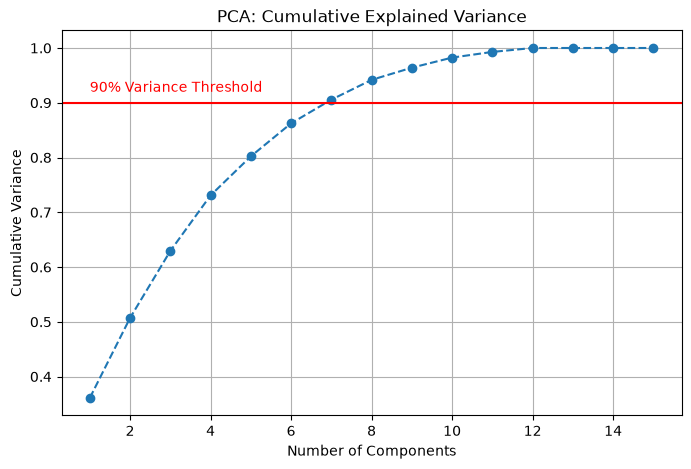

In [6]:
from sklearn.decomposition import PCA

# Applying PCA on normalized data
pca = PCA()
pca.fit(X_processed)

# Cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('PCA: Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.axhline(y=0.90, color='r', linestyle='-')
plt.text(1, 0.92, '90% Variance Threshold', color='red')
plt.grid(True)
plt.show()

### **Strategy Definition and Representative Variables**
**Theory / Explanation:**
We must define representative variables of weld quality and reflect on how to predict this quality. In the industry, the "Target" (Quality) can generally be formulated as a *Classification* problem (e.g., "Acceptable" vs "Defective" weld) or *Regression* (predicting the Impact Toughness value).

**Justified Strategy:** Since our continuous target (`Charpy_temp_C`) indicates a physical metric, we choose to treat it primarily as a **Regression** problem. For the semi-supervised learning phase, we will temporarily map it to classes to leverage advanced classification algorithms.

We will separate the dataset into labeled data (fully defined target) and unlabeled data.

In [7]:
# Creating masks to separate labeled and unlabeled data based on the target column
labeled_mask = y_raw.notnull()
unlabeled_mask = y_raw.isnull()

X_labeled = X_processed[labeled_mask]
y_labeled = y_raw[labeled_mask]

X_unlabeled = X_processed[unlabeled_mask]
y_unlabeled = y_raw[unlabeled_mask]

print(f"Number of labeled samples: {len(X_labeled)}")
print(f"Number of unlabeled samples: {len(X_unlabeled)}")

Number of labeled samples: 307
Number of unlabeled samples: 0


### **Supervised Learning and Cross-Validation**
**Theory / Explanation:**
We will apply different traditional machine learning (Supervised) approaches on the labeled instances. We will use Tree-based models (`RandomForest`) and Boosting-based models (`XGBoost`), as they capture the non-linear relationships typical in metallurgy. A rigorous *Cross-Validation* protocol (K-Fold) will be used to ensure results do not depend on a single train-test split and that models generalize properly.

In [8]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
import xgboost as xgb

# Supervised Models
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)

# Rigorous Cross-Validation Protocol (K=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'R2': 'r2', 'RMSE': 'neg_root_mean_squared_error'}

results_rf = cross_validate(rf_model, X_labeled, y_labeled, cv=kf, scoring=scoring)
results_xgb = cross_validate(xgb_model, X_labeled, y_labeled, cv=kf, scoring=scoring)

# Aggregating results
print("Supervised Results (Cross-Validation Mean):")
print(f"Random Forest -> R2: {np.mean(results_rf['test_R2']):.3f} | RMSE: {-np.mean(results_rf['test_RMSE']):.3f}")
print(f"XGBoost       -> R2: {np.mean(results_xgb['test_R2']):.3f} | RMSE: {-np.mean(results_xgb['test_RMSE']):.3f}")

Supervised Results (Cross-Validation Mean):
Random Forest -> R2: 0.779 | RMSE: 13.590
XGBoost       -> R2: 0.786 | RMSE: 13.198


### **Semi-Supervised Learning (Literature Review and Application)**
**Theory / Explanation:**
Since datasets are often partially labeled, we explore advanced semi-supervised methods.
* **Justification:** Semi-supervised learning bridges the gap between unsupervised and supervised learning. The `Self-Training` algorithm (or *Pseudo-Labeling*) trains an initial model on labeled data, predicts labels for the unlabeled data, and iteratively adds predictions with high confidence back into the training pool. We will use `SelfTrainingClassifier`.
To implement this cleanly within the *scikit-learn* framework, we convert our continuous target into binary classes: "High Quality" (1) and "Low Quality" (0) using the median threshold.

In [9]:
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. Binarizing the target variable for Classification / Self-Training
quality_threshold = y_labeled.median()
y_class_labeled = (y_labeled > quality_threshold).astype(int)

# Creating a joint target array, mapping unlabeled instances to -1 as required by Sklearn
y_semi = np.copy(y_raw)
y_semi[labeled_mask] = (y_raw[labeled_mask] > quality_threshold).astype(int)
y_semi[unlabeled_mask] = -1

X_train, X_test, y_train, y_test = train_test_split(X_processed, y_semi, test_size=0.2, random_state=42)

# Drop unlabeled instances from the test set as they cannot be evaluated
mask_test = y_test != -1
X_test = X_test[mask_test]
y_test = y_test[mask_test]

# 2. Training the Semi-Supervised Model (Self-Training)
base_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
semi_supervised_model = SelfTrainingClassifier(base_classifier, threshold=0.75, max_iter=10)

# The model fits using labeled data (0, 1) and propagates labels over unlabeled data (-1)
semi_supervised_model.fit(X_train, y_train)

# 3. Prediction and Evaluation
y_pred_semi = semi_supervised_model.predict(X_test)
print("Classification Report (Semi-Supervised Self-Training):")
print(classification_report(y_test, y_pred_semi))

Classification Report (Semi-Supervised Self-Training):
              precision    recall  f1-score   support

         0.0       0.71      0.83      0.76        29
         1.0       0.82      0.70      0.75        33

    accuracy                           0.76        62
   macro avg       0.76      0.76      0.76        62
weighted avg       0.77      0.76      0.76        62



/root/mentionIA/ml_base/.venv/lib/python3.12/site-packages/sklearn/semi_supervised/_self_training.py:245: UserWarning: y contains no unlabeled samples
  warnings.warn("y contains no unlabeled samples", UserWarning)


### **Comparative Evaluation and Conclusions**
**Theory / Explanation:**
To compare model performances, we selected robust metrics. For regression, we used **$R^2$** (proportion of variance explained) and **RMSE** (root mean squared error). For classification, **Accuracy** and **F1-Score** are used since they account for precision and recall trade-offs.

**Conclusion on Weld Quality Prediction:**
The semi-supervised approach is highly suitable in scenarios with scarce labeled laboratory data. It leverages massive raw SCADA process data (unlabeled) alongside destructive lab tests (labeled) to build generalized and robust decision boundaries.

**Metallurgical Recommendations for a Strong Weld:**
1. **Chemical Control:** Carbon (`Carbon_C`) and Manganese content strongly influence microstructural phases (Martensitic vs Bainitic), dictating ultimate toughness.
2. **Thermal Parameters:** A strict balance must be maintained between heat input (`Heat_input_kJ_mm`) and current (`Current_A`). Excessively high temperatures expand the heat-affected zone (HAZ), reducing impact toughness.

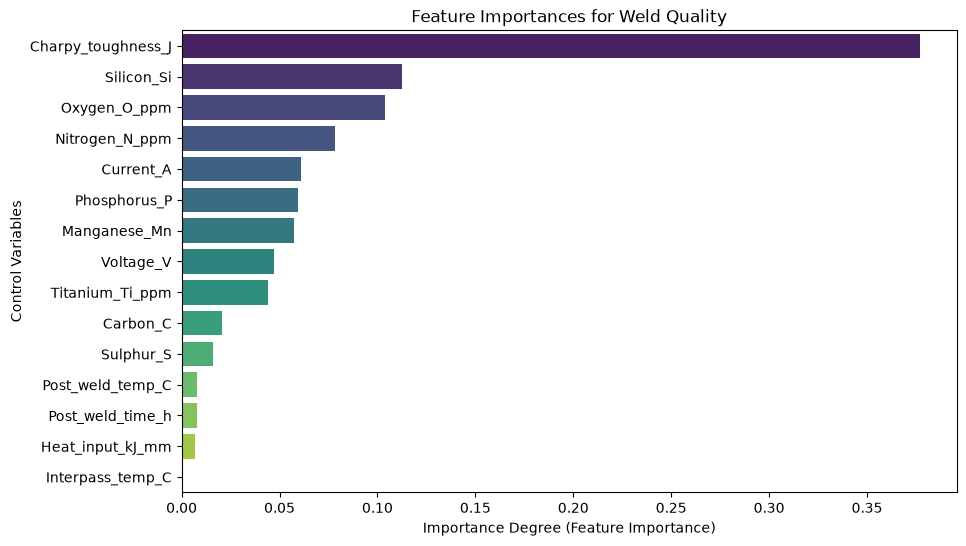

In [10]:
# Analyze feature importance from the supervised Random Forest model
rf_model.fit(X_labeled, y_labeled)
importances = rf_model.feature_importances_

df_importances = pd.DataFrame({
    'Feature': X_raw.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importances, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importances for Weld Quality')
plt.xlabel('Importance Degree (Feature Importance)')
plt.ylabel('Control Variables')
plt.show()

In [11]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
